## Training

In [1]:
# setup

import sys
import torch
import json
from pathlib import Path
from torch.utils.data import DataLoader

sys.path.append(str(Path.cwd().parent / "src"))

from data import build_vocab, encode, make_chunks, CharDataset, find_anchor_positions, ANCHOR_NAMES
from rnn import VanillaRNN
from lstm import LSTMModel
from train import train

device = torch.device("cpu")
print(f"Device: {device}")
print(f"PyTorch version: {torch.__version__}")

Device: cpu
PyTorch version: 2.14.0+cpu


In [2]:
# reloading the cleaned corpus and rebuilding the vocab

PROCESSED_DATA_DIR = Path.cwd().parent / "data" / "processed"

with open(PROCESSED_DATA_DIR / "corpus_clean.txt", "r", encoding="utf-8") as f:
    text = f.read()

# split boundaries decided in notebook 01
train_text = text[:738058]
val_text   = text[738058:897611]
test_text  = text[897611:]

# building vocab from train only
char2idx, idx2char = build_vocab(train_text, min_count=10)
vocab_size = len(idx2char)

train_encoded = encode(train_text, char2idx)
val_encoded   = encode(val_text,   char2idx)
test_encoded  = encode(test_text,  char2idx)

print(f"Vocab size:       {vocab_size}")
print(f"Train chars:      {len(train_encoded):,}")
print(f"Val chars:        {len(val_encoded):,}")
print(f"Test chars:       {len(test_encoded):,}")

Vocab size:       71
Train chars:      738,058
Val chars:        159,553
Test chars:       233,677


In [3]:
# chunking all three splits and wrapping in DataLoaders

SEQ_LEN    = 100
BATCH_SIZE = 64

train_chunks = make_chunks(train_encoded, seq_len=SEQ_LEN)
val_chunks   = make_chunks(val_encoded,   seq_len=SEQ_LEN)
test_chunks  = make_chunks(test_encoded,  seq_len=SEQ_LEN)

train_loader = DataLoader(CharDataset(train_chunks), batch_size=BATCH_SIZE,
                          shuffle=True,  drop_last=True)
val_loader   = DataLoader(CharDataset(val_chunks),   batch_size=BATCH_SIZE,
                          shuffle=False, drop_last=True)
test_loader  = DataLoader(CharDataset(test_chunks),  batch_size=BATCH_SIZE,
                          shuffle=False, drop_last=True)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

Train batches: 115
Val batches:   24
Test batches:  36


In [4]:
# RNN training run for 20 epochs

CHECKPOINT_DIR = Path.cwd().parent / "checkpoints"
CHECKPOINT_DIR.mkdir(exist_ok=True)

NUM_EPOCHS = 20

print("=" * 60)
print("TRAINING: Vanilla RNN")
print("=" * 60)

rnn_model = VanillaRNN(vocab_size=vocab_size, embed_dim=64, hidden_size=256)

rnn_train_losses, rnn_val_losses = train(
    rnn_model, train_loader, val_loader,
    num_epochs=NUM_EPOCHS, lr=0.001, device=device,
    model_type="rnn",
    save_path=str(CHECKPOINT_DIR / "rnn_best.pt")
)

TRAINING: Vanilla RNN
Epoch 1/20 | Train Loss: 2.5416 | Val Loss: 2.1947 | Train Perplexity: 12.70 | Val Perplexity: 8.98
  → Saved best checkpoint (val loss: 2.1947)
Epoch 2/20 | Train Loss: 2.0178 | Val Loss: 1.9510 | Train Perplexity: 7.52 | Val Perplexity: 7.04
  → Saved best checkpoint (val loss: 1.9510)
Epoch 3/20 | Train Loss: 1.8373 | Val Loss: 1.8140 | Train Perplexity: 6.28 | Val Perplexity: 6.13
  → Saved best checkpoint (val loss: 1.8140)
Epoch 4/20 | Train Loss: 1.7300 | Val Loss: 1.7278 | Train Perplexity: 5.64 | Val Perplexity: 5.63
  → Saved best checkpoint (val loss: 1.7278)
Epoch 5/20 | Train Loss: 1.6581 | Val Loss: 1.6665 | Train Perplexity: 5.25 | Val Perplexity: 5.29
  → Saved best checkpoint (val loss: 1.6665)
Epoch 6/20 | Train Loss: 1.6059 | Val Loss: 1.6272 | Train Perplexity: 4.98 | Val Perplexity: 5.09
  → Saved best checkpoint (val loss: 1.6272)
Epoch 7/20 | Train Loss: 1.5663 | Val Loss: 1.5933 | Train Perplexity: 4.79 | Val Perplexity: 4.92
  → Saved best

In [ ]:
# LSTM training run for 20 epochs

print("=" * 60)
print("TRAINING: LSTM")
print("=" * 60)

lstm_model = LSTMModel(vocab_size=vocab_size, embed_dim=64, hidden_size=256)

lstm_train_losses, lstm_val_losses = train(
    lstm_model, train_loader, val_loader,
    num_epochs=NUM_EPOCHS, lr=0.001, device=device,
    model_type="lstm",
    save_path=str(CHECKPOINT_DIR / "lstm_best.pt")
)

TRAINING: LSTM
Epoch 1/20 | Train Loss: 2.7653 | Val Loss: 2.3561 | Train Perplexity: 15.88 | Val Perplexity: 10.55
  → Saved best checkpoint (val loss: 2.3561)
Epoch 2/20 | Train Loss: 2.1727 | Val Loss: 2.0896 | Train Perplexity: 8.78 | Val Perplexity: 8.08
  → Saved best checkpoint (val loss: 2.0896)
Epoch 3/20 | Train Loss: 1.9740 | Val Loss: 1.9442 | Train Perplexity: 7.20 | Val Perplexity: 6.99
  → Saved best checkpoint (val loss: 1.9442)
Epoch 4/20 | Train Loss: 1.8520 | Val Loss: 1.8401 | Train Perplexity: 6.37 | Val Perplexity: 6.30
  → Saved best checkpoint (val loss: 1.8401)
Epoch 5/20 | Train Loss: 1.7645 | Val Loss: 1.7645 | Train Perplexity: 5.84 | Val Perplexity: 5.84
  → Saved best checkpoint (val loss: 1.7645)
Epoch 6/20 | Train Loss: 1.6994 | Val Loss: 1.7083 | Train Perplexity: 5.47 | Val Perplexity: 5.52
  → Saved best checkpoint (val loss: 1.7083)
Epoch 7/20 | Train Loss: 1.6467 | Val Loss: 1.6627 | Train Perplexity: 5.19 | Val Perplexity: 5.27
  → Saved best check

In [6]:
# saving loss histories

RESULTS_DIR = Path.cwd().parent / "results"
RESULTS_DIR.mkdir(exist_ok=True)

loss_history = {
    "rnn_train_losses":  rnn_train_losses,
    "rnn_val_losses":    rnn_val_losses,
    "lstm_train_losses": lstm_train_losses,
    "lstm_val_losses":   lstm_val_losses,
}

with open(RESULTS_DIR / "loss_history.json", "w") as f:
    json.dump(loss_history, f, indent=2)

print("Loss histories saved to results/loss_history.json")

Loss histories saved to results/loss_history.json


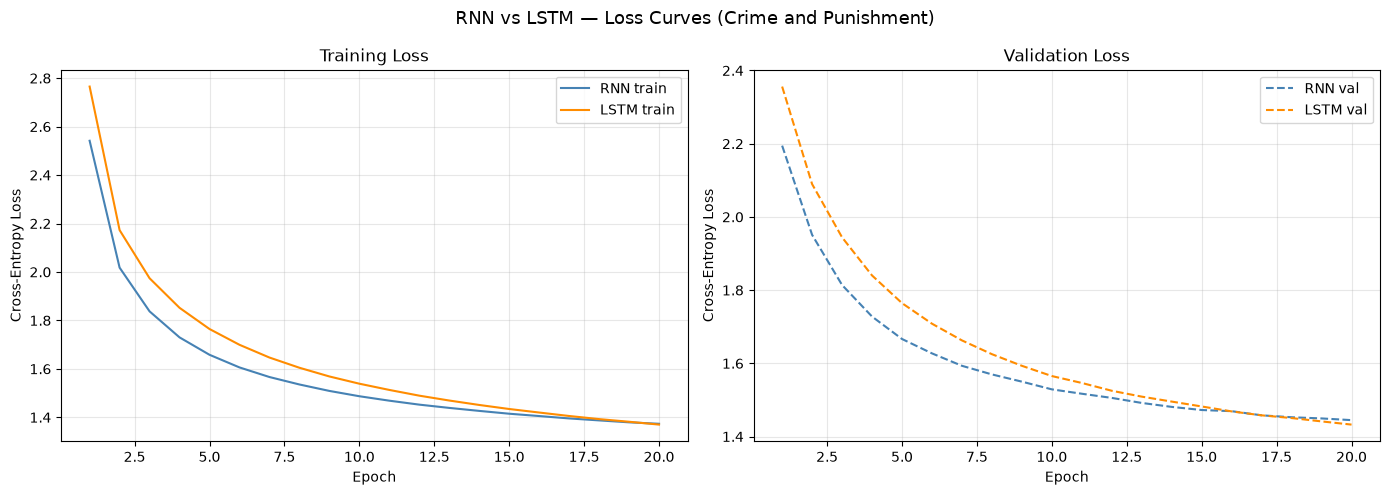

Saved to results/figures/loss_curves.png


In [ ]:
# plotting side-by-side loss curves for both models

import matplotlib.pyplot as plt

epochs = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# train loss comparison
axes[0].plot(epochs, rnn_train_losses,  label="RNN train",  color="steelblue",  linestyle="-")
axes[0].plot(epochs, lstm_train_losses, label="LSTM train", color="darkorange", linestyle="-")
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

# val loss comparison
axes[1].plot(epochs, rnn_val_losses,  label="RNN val",  color="steelblue",  linestyle="--")
axes[1].plot(epochs, lstm_val_losses, label="LSTM val", color="darkorange", linestyle="--")
axes[1].set_title("Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Cross-Entropy Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("RNN vs LSTM — Loss Curves (Crime and Punishment)", fontsize=13)
plt.tight_layout()

FIGURES_DIR = Path.cwd().parent / "results" / "figures"
FIGURES_DIR.mkdir(exist_ok=True)
plt.savefig(FIGURES_DIR / "loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to results/figures/loss_curves.png")